# CV: Классификация жанра фильма по постеру

**Задача:** многоклассовая классификация (7 жанров) по изображению постера.

**Бизнес-смысл:** модель оценивает насколько постер соответствует жанру фильма.
Низкая уверенность модели при правильном жанре, следовательно фильм - кандидат на замену своего постера.

**Данные:** `data/processed/tmdb_cv.csv` — 987 постеров × 7 жанров (Action,
Adventure, Comedy, Crime, Drama, Horror, Thriller), датасет сбалансирован.

**План ноутбука:**
1. Загрузка и сплит
2. трансформации и аугментации
4. общий цикл обучения с early stopping
6. Архитектура 1 (CNN с нуля)
7. Архитектура 2 (ResNet-18 fine-tuning)
8. Архитектура 3 (EfficientNet-B0)
9. сравнение архитектур

**Решения, принятые в ходе EDA для этой задачи:**

- Для классификации использован primary_genre (первый жанр из списка) — задача сведена к multi-class, а не multi-label
- Топ-7 самых частых жанров выбраны для обучения: Action, Adventure, Comedy, Crime, Drama, Horror, Thriller
- Целевой баланс — 1000 постеров на жанр; фактически получено 987×7=6909 после потерь при скачивании
- Постеры получены через TMDB API (image.tmdb.org/t/p/w500) по полю poster_path, привязаны к фильмам через id

## 0. Импорты

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import mlflow
import mlflow.pytorch

torch.manual_seed(67)
np.random.seed(67)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

IMG_SIZE = 224
POSTERS_DIR = Path('../data/raw/posters/downloaded')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

Device: mps


## 1. Загрузка данных и разбиение
настройка окружения и устройства вычислений; кодирование жанров в числовые индексы; стратифицированный train/val/test split, сохраняющий баланс классов во всех трёх выборках.

In [95]:
df = pd.read_csv('../data/processed/tmdb_cv.csv')
len(df)

6909

Скрипт, скачивавший постеры, редактировал датасет с фильмами для нашей задачи, в зависимости от того, удалось ли скачать постер или нет, а именно он дропал строки, у которых не оказалось постера, а затем отбалансировал количество постеров, чтобы ни у одного жанра не было перевеса. Изначально у каждого жанра должно было быть ровно по 1000 постеров, но у одного из них скачалось лишь 987. Пришлось подрезать количество и для остальных. Остальные жанры (кроме этих семи) не были выбраны, потому что у них просто в отфильтрованном датасете не набиралось 1000 постеров.

In [96]:
df['primary_genre'].value_counts()

primary_genre
Action       987
Adventure    987
Comedy       987
Crime        987
Drama        987
Horror       987
Thriller     987
Name: count, dtype: int64

In [97]:
genre_classes = sorted(df['primary_genre'].unique())
genre_to_idx = {g: i for i, g in enumerate(genre_classes)}
idx_to_genre = {i: g for g, i in genre_to_idx.items()}

df['genre_idx'] = df['primary_genre'].map(genre_to_idx)
df['poster_file'] = df['id'].astype(str) + '.jpg'

genre_classes

['Action', 'Adventure', 'Comedy', 'Crime', 'Drama', 'Horror', 'Thriller']

Эти жанры были выбраны

80/10/10 split, стратифицированный по жанру для сохранения баланса

При 6909 изображениях на 7 классов (987 на класс) большая тренировочная выборка особенно важна для CNN с нуля, у которой нет преимущества предобученных весов. 80/10/10 даёт train 790 на класс против val/test 99 на класс.

In [98]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=67, stratify=df['genre_idx']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=67, stratify=temp_df['genre_idx']
)

In [99]:
# train
len(train_df)

5527

In [100]:
# val
len(val_df)

691

In [101]:
# test
len(test_df)

691

Баланс по жанрам в трейне

In [102]:
train_df['primary_genre'].value_counts()

primary_genre
Drama        790
Thriller     790
Action       790
Adventure    790
Crime        789
Comedy       789
Horror       789
Name: count, dtype: int64

## 2. Трансформации и Dataset

для train применяются аугментации (RandomCrop, RandomHorizontalFlip) для повышения устойчивости модели, для val/test — только детерминированный resize и нормализация по статистикам ImageNet.

In [103]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [104]:
class PosterDataset(Dataset):
    def __init__(self, df, posters_dir, transform):
        self.df = df.reset_index(drop=True)
        self.posters_dir = posters_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.posters_dir / row['poster_file']
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        label = row['genre_idx']
        return image, label


BATCH_SIZE = 32

train_ds = PosterDataset(train_df, POSTERS_DIR, train_transform)
val_ds = PosterDataset(val_df, POSTERS_DIR, eval_transform)
test_ds = PosterDataset(test_df, POSTERS_DIR, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [105]:
# train batches
len(train_loader)

173

In [106]:
# val batches
len(val_loader)

22

In [107]:
# test batches
len(test_loader)

22

посмотрим, как себя чувствуют постеры сейчас

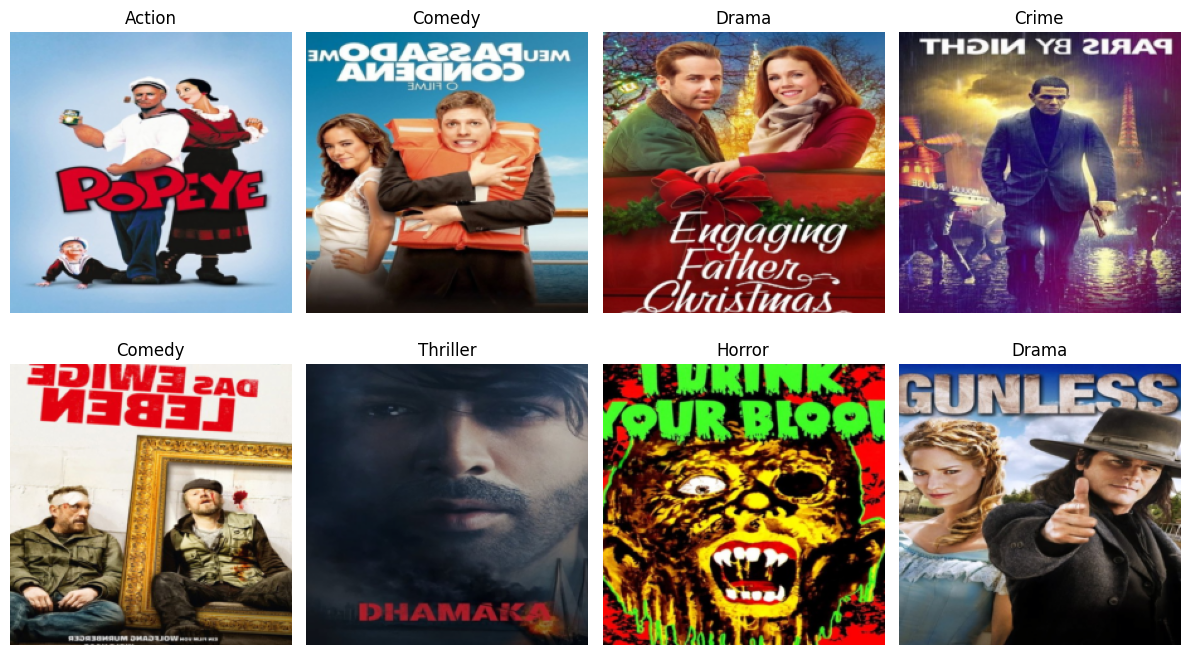

In [108]:
def show_batch(images, labels, n=8):
    images = images[:n].numpy().transpose(0, 2, 3, 1)
    images = images * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    images = np.clip(images, 0, 1)

    fig, axes = plt.subplots(2, 4, figsize=(12, 7))
    for ax, img, label in zip(axes.flatten(), images, labels[:n]):
        ax.imshow(img)
        ax.set_title(idx_to_genre[label.item()])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

images, labels = next(iter(train_loader))
show_batch(images, labels)

## 3. Обучающий цикл
единая функция обучения с early stopping по val_loss, обеспечивающая идентичные условия сравнения для всех трёх архитектур.

In [109]:
from tqdm.auto import tqdm


def train_cv_model(model, train_loader, val_loader, epochs=15, lr=1e-3,
                    optimizer=None, scheduler=None, patience=5):
    model = model.to(device)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        # Train
        model.train()
        train_losses, train_correct, train_total = [], 0, 0
        train_pbar = tqdm(train_loader,
                          desc=f'Epoch {epoch+1}/{epochs} [train]',
                          leave=True)
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            train_pbar.set_postfix({
                'loss': f'{np.mean(train_losses):.4f}',
                'acc': f'{train_correct / train_total:.4f}'
            })

        # Val
        model.eval()
        val_losses, val_correct, val_total = [], 0, 0
        val_pbar = tqdm(val_loader,
                        desc=f'Epoch {epoch+1}/{epochs} [val]  ',
                        leave=True)
        with torch.no_grad():
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_losses.append(loss.item())
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                val_pbar.set_postfix({
                    'loss': f'{np.mean(val_losses):.4f}',
                    'acc': f'{val_correct / val_total:.4f}'
                })

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if scheduler is not None:
            scheduler.step()

        tqdm.write(f'Epoch {epoch+1:2d}/{epochs} | '
                   f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
                   f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            tqdm.write(f'Early stopping at epoch {epoch+1} (best val_loss={best_val_loss:.4f})')
            break

    model.load_state_dict(best_state)
    return model, history


def evaluate_cv_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
            all_probs.append(probs.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return {'accuracy': acc, 'f1_macro': f1}, all_preds, all_labels, all_probs

## 4. MLflow setup

In [110]:
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment('tmdb_poster_genre_classification')

<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1781360142395, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781360142395, lifecycle_stage='active', name='tmdb_poster_genre_classification', tags={}, trace_location=None, workspace='default'>

## 5. Архитектура 1 — CNN с нуля

По аналогии с CIFAR_Net: чередование Conv2d, BatchNorm2d, ReLU, MaxPool,
затем полносвязные слои с Dropout. Адаптировано под вход 224×224×3 и 7 классов.

In [111]:
class PosterCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(PosterCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.batch_norm1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.batch_norm2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.batch_norm3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
        self.batch_norm4 = nn.BatchNorm2d(128)
        self.pool4 = nn.MaxPool2d(2, 2)

        # Global Average Pooling вместо Flatten - резко сокращает параметры FC-головы
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(128, 64)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.batch_norm1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.batch_norm2(self.conv2(x)))
        x = self.pool2(x)

        x = F.relu(self.batch_norm3(self.conv3(x)))
        x = self.pool3(x)

        x = F.relu(self.batch_norm4(self.conv4(x)))
        x = self.pool4(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        return x

In [112]:
params_cnn = {
    'architecture': 'CNN_from_scratch_v2',
    'conv_layers': [32, 64, 128, 128],
    'pooling': 'GlobalAveragePooling',
    'fc_layers': [64],
    'dropout': 0.4,
    'lr': 1e-3,
    'epochs': 10,
    'batch_size': BATCH_SIZE,
    'image_size': IMG_SIZE,
    'patience': 8
}

with mlflow.start_run(run_name='CNN_from_scratch_v2'):
    mlflow.log_params(params_cnn)

    model_cnn = PosterCNN(num_classes=len(genre_classes))
    optimizer = torch.optim.Adam(model_cnn.parameters(), lr=params_cnn['lr'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    model_cnn, history_cnn = train_cv_model(
        model_cnn, train_loader, val_loader,
        epochs=params_cnn['epochs'], optimizer=optimizer, patience=params_cnn['patience']
    )

    for epoch, (tl, vl, ta, va) in enumerate(zip(
        history_cnn['train_loss'], history_cnn['val_loss'],
        history_cnn['train_acc'], history_cnn['val_acc']
    )):
        mlflow.log_metrics({'train_loss': tl, 'val_loss': vl, 'train_acc': ta, 'val_acc': va}, step=epoch)

    metrics_cnn, preds_cnn, labels_cnn, probs_cnn = evaluate_cv_model(model_cnn, test_loader)
    mlflow.log_metrics({'test_accuracy': metrics_cnn['accuracy'], 'test_f1_macro': metrics_cnn['f1_macro']})

    mlflow.pytorch.log_model(model_cnn, 'model')

    print(f"\nTest Accuracy: {metrics_cnn['accuracy']:.4f} | F1 (macro): {metrics_cnn['f1_macro']:.4f}")

Epoch 1/10 [val]  : 100%|██████████| 22/22 [00:05<00:00,  4.11it/s, loss=1.8667, acc=0.2605]


Epoch  1/10 | train_loss=1.8621 train_acc=0.2329 | val_loss=1.8667 val_acc=0.2605


Epoch 2/10 [val]  : 100%|██████████| 22/22 [00:04<00:00,  4.46it/s, loss=1.8039, acc=0.3039]


Epoch  2/10 | train_loss=1.8381 train_acc=0.2538 | val_loss=1.8039 val_acc=0.3039


Epoch 3/10 [val]  : 100%|██████████| 22/22 [00:04<00:00,  4.55it/s, loss=1.7977, acc=0.2735]


...

Epoch  9/10 | train_loss=1.7767 train_acc=0.2889 | val_loss=1.7624 val_acc=0.3039


Epoch 10/10 [val]  : 100%|██████████| 22/22 [00:04<00:00,  4.52it/s, loss=1.7608, acc=0.2967]


Epoch 10/10 | train_loss=1.7747 train_acc=0.2904 | val_loss=1.7608 val_acc=0.2967


Evaluating: 100%|██████████| 22/22 [00:05<00:00,  4.02it/s]
2026/06/16 09:03:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 09:03:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Test Accuracy: 0.2735 | F1 (macro): 0.2633
🏃 View run CNN_from_scratch_v2 at: http://127.0.0.1:5000/#/experiments/3/runs/045dbf85489a4744bc82edc11b1d58fd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 6. Архитектура 2 — ResNet-18 fine-tuning с differential learning rates

В отличие от базового подхода из семинара (полная заморозка backbone + один lr для
классификатора), здесь используется **differential learning rate**: backbone обучается
с очень малым lr (тонкая подстройка предобученных весов под постеры), а новый
классификатор — с обычным lr (учится с нуля).

In [124]:
resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

num_in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_in_features, len(genre_classes))
)

num_in_features

512

input

In [125]:
len(genre_classes)

7

output

In [114]:
params_resnet = {
    'architecture': 'ResNet18_finetuning_v2',
    'pretrained': 'ImageNet',
    'backbone_lr': 5e-5,
    'classifier_lr': 5e-4,
    'scheduler': 'ReduceLROnPlateau',
    'dropout': 0.3,
    'epochs': 10,
    'batch_size': BATCH_SIZE,
    'image_size': IMG_SIZE,
    'patience': 8
}

with mlflow.start_run(run_name='ResNet18_finetuning_v2'):
    mlflow.log_params(params_resnet)

    optimizer_params = [
        {'params': [p for n, p in resnet.named_parameters() if not n.startswith('fc')], 'lr': params_resnet['backbone_lr']},
        {'params': resnet.fc.parameters(), 'lr': params_resnet['classifier_lr']},
    ]
    optimizer = torch.optim.Adam(optimizer_params, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    model_resnet, history_resnet = train_cv_model(
        resnet, train_loader, val_loader,
        epochs=params_resnet['epochs'], optimizer=optimizer, scheduler=None,
        patience=params_resnet['patience']
    )

    for epoch, (tl, vl, ta, va) in enumerate(zip(
        history_resnet['train_loss'], history_resnet['val_loss'],
        history_resnet['train_acc'], history_resnet['val_acc']
    )):
        mlflow.log_metrics({'train_loss': tl, 'val_loss': vl, 'train_acc': ta, 'val_acc': va}, step=epoch)

    metrics_resnet, preds_resnet, labels_resnet, probs_resnet = evaluate_cv_model(model_resnet, test_loader)
    mlflow.log_metrics({'test_accuracy': metrics_resnet['accuracy'], 'test_f1_macro': metrics_resnet['f1_macro']})

    mlflow.pytorch.log_model(model_resnet, 'model')

    print(f"\nTest Accuracy: {metrics_resnet['accuracy']:.4f} | F1 (macro): {metrics_resnet['f1_macro']:.4f}")

Epoch 1/10 [val]  : 100%|██████████| 22/22 [00:06<00:00,  3.47it/s, loss=1.5923, acc=0.3907]


Epoch  1/10 | train_loss=1.7803 train_acc=0.3049 | val_loss=1.5923 val_acc=0.3907


Epoch 2/10 [val]  : 100%|██████████| 22/22 [00:08<00:00,  2.58it/s, loss=1.6086, acc=0.3835]


Epoch  2/10 | train_loss=1.5122 train_acc=0.4183 | val_loss=1.6086 val_acc=0.3835


Epoch 3/10 [val]  : 100%|██████████| 22/22 [00:06<00:00,  3.54it/s, loss=1.6390, acc=0.3763]


...

Epoch  8/10 | train_loss=0.4067 train_acc=0.8737 | val_loss=2.3600 val_acc=0.3575


Epoch 9/10 [val]  : 100%|██████████| 22/22 [00:06<00:00,  3.61it/s, loss=2.5547, acc=0.3285]


Epoch  9/10 | train_loss=0.2872 train_acc=0.9104 | val_loss=2.5547 val_acc=0.3285
Early stopping at epoch 9 (best val_loss=1.5923)


Evaluating: 100%|██████████| 22/22 [00:06<00:00,  3.31it/s]
2026/06/16 09:23:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 09:23:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



Test Accuracy: 0.3676 | F1 (macro): 0.3592
🏃 View run ResNet18_finetuning_v2 at: http://127.0.0.1:5000/#/experiments/3/runs/d08717b147c84766a0dea2b17095bdc4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 7. Архитектура 3 — EfficientNet-B0

EfficientNet использует compound scaling (одновременное масштабирование глубины,
ширины и разрешения) — подход не рассматривался на семинарах. Лёгкая модель,
хорошо работает на небольших датасетах.

Установка: `pip install timm`

In [126]:
import timm

effnet = timm.create_model('efficientnet_b0', pretrained=True, num_classes=len(genre_classes), drop_rate=0.3)

sum(p.numel() for p in effnet.parameters())

4016515

количество параметров

In [116]:
params_effnet = {
    'architecture': 'EfficientNet_B0_v2',
    'pretrained': 'ImageNet',
    'backbone_lr': 1e-4,
    'classifier_lr': 1e-3,
    'drop_rate': 0.3,
    'epochs': 10,
    'batch_size': BATCH_SIZE,
    'image_size': IMG_SIZE,
    'patience': 8
}

with mlflow.start_run(run_name='EfficientNet_B0_v2'):
    mlflow.log_params(params_effnet)

    optimizer_params = [
        {'params': [p for n, p in effnet.named_parameters() if not n.startswith('classifier')], 'lr': params_effnet['backbone_lr']},
        {'params': effnet.classifier.parameters(), 'lr': params_effnet['classifier_lr']},
    ]
    optimizer = torch.optim.Adam(optimizer_params, weight_decay=1e-4)

    model_effnet, history_effnet = train_cv_model(
        effnet, train_loader, val_loader,
        epochs=params_effnet['epochs'], optimizer=optimizer, scheduler=None,
        patience=params_effnet['patience']
    )

    for epoch, (tl, vl, ta, va) in enumerate(zip(
        history_effnet['train_loss'], history_effnet['val_loss'],
        history_effnet['train_acc'], history_effnet['val_acc']
    )):
        mlflow.log_metrics({'train_loss': tl, 'val_loss': vl, 'train_acc': ta, 'val_acc': va}, step=epoch)

    metrics_effnet, preds_effnet, labels_effnet, probs_effnet = evaluate_cv_model(model_effnet, test_loader)
    mlflow.log_metrics({'test_accuracy': metrics_effnet['accuracy'], 'test_f1_macro': metrics_effnet['f1_macro']})

    mlflow.pytorch.log_model(model_effnet, 'model')

    print(f"\nTest Accuracy: {metrics_effnet['accuracy']:.4f} | F1 (macro): {metrics_effnet['f1_macro']:.4f}")

Epoch 1/10 [val]  : 100%|██████████| 22/22 [00:29<00:00,  1.33s/it, loss=2.2818, acc=0.2967]


Epoch  1/10 | train_loss=3.2496 train_acc=0.2339 | val_loss=2.2818 val_acc=0.2967


Epoch 2/10 [val]  : 100%|██████████| 22/22 [00:12<00:00,  1.70it/s, loss=1.9943, acc=0.3169]


Epoch  2/10 | train_loss=1.9245 train_acc=0.3629 | val_loss=1.9943 val_acc=0.3169


Epoch 3/10 [val]  : 100%|██████████| 22/22 [00:12<00:00,  1.71it/s, loss=1.9576, acc=0.3271]


...

Epoch  9/10 | train_loss=0.4875 train_acc=0.8308 | val_loss=2.3795 val_acc=0.3415


Epoch 10/10 [val]  : 100%|██████████| 22/22 [00:09<00:00,  2.31it/s, loss=2.5025, acc=0.3502]


Epoch 10/10 | train_loss=0.3779 train_acc=0.8788 | val_loss=2.5025 val_acc=0.3502


Evaluating: 100%|██████████| 22/22 [00:33<00:00,  1.50s/it]
2026/06/16 11:09:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 11:10:00 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
Python(35640) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



Test Accuracy: 0.3444 | F1 (macro): 0.3435
🏃 View run EfficientNet_B0_v2 at: http://127.0.0.1:5000/#/experiments/3/runs/931ab75f58c04738941bfdb58c249b4c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 8. Сравнение архитектур
количественное сопоставление Accuracy/F1 и визуальный анализ того, какие жанры путаются между собой.

          Architecture  Accuracy  F1 (macro)
      CNN from scratch  0.273517    0.263273
ResNet-18 (fine-tuned)  0.367583    0.359215
       EfficientNet-B0  0.344428    0.343482


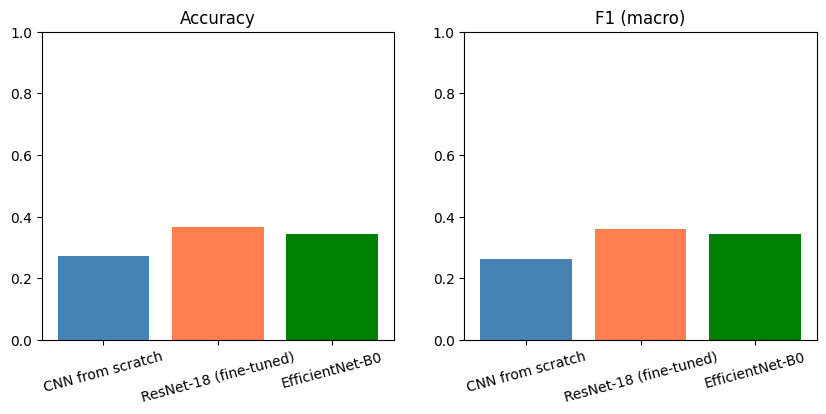

In [117]:
comparison = pd.DataFrame({
    'Architecture': ['CNN from scratch', 'ResNet-18 (fine-tuned)', 'EfficientNet-B0'],
    'Accuracy': [metrics_cnn['accuracy'], metrics_resnet['accuracy'], metrics_effnet['accuracy']],
    'F1 (macro)': [metrics_cnn['f1_macro'], metrics_resnet['f1_macro'], metrics_effnet['f1_macro']],
})

print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['Accuracy', 'F1 (macro)']):
    ax.bar(comparison['Architecture'], comparison[metric], color=['steelblue', 'coral', 'green'])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)

plt.savefig('../data/processed/cv_comparison.png')
plt.show()

ResNet-18 показал лучший результат (Accuracy=0.368, F1=0.359), за ним EfficientNet-B0 (0.344/0.343), CNN с нуля заметно отстаёт (0.274/0.263). Все три модели превосходят случайный baseline для 7 классов (0.143), но с разным отрывом — transfer learning даёт ResNet и EfficientNet ощутимое преимущество над обучением с нуля.

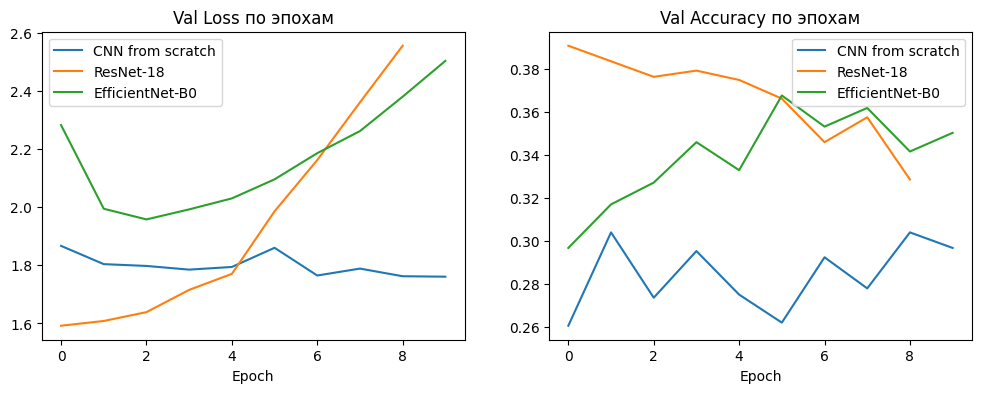

In [118]:
# Training curves для всех трёх моделей
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cnn['val_loss'], label='CNN from scratch')
axes[0].plot(history_resnet['val_loss'], label='ResNet-18')
axes[0].plot(history_effnet['val_loss'], label='EfficientNet-B0')
axes[0].set_title('Val Loss по эпохам')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_cnn['val_acc'], label='CNN from scratch')
axes[1].plot(history_resnet['val_acc'], label='ResNet-18')
axes[1].plot(history_effnet['val_acc'], label='EfficientNet-B0')
axes[1].set_title('Val Accuracy по эпохам')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.savefig('../data/processed/cv_training_curves.png')
plt.show()

График показывает тревожную картину для обеих предобученных моделей. ResNet-18 достигает пика accuracy уже на 1-й эпохе, после чего val_loss монотонно растёт, а accuracy падает — явный признак переобучения: backbone с увеличенным lr и добавленный Dropout сдвинули баланс не в сторону лучшей генерализации, а в сторону более быстрой подгонки под train с последующей потерей качества на валидации. EfficientNet-B0 ведёт себя похоже, но более плавно — val_loss растёт от первой эпохи практически линейно, без выраженного пика, что говорит о том, что модель не успела толком сойтись прежде чем начала переобучаться. CNN с нуля — единственная модель с относительно стабильной (хотя и шумной) кривой без выраженного тренда на ухудшение, но и без значимого улучшения после начальных эпох — это согласуется с её более низким абсолютным качеством: модель быстро достигает своего потолка на ограниченном объёме данных без предобученных весов.

## 9. Confusion Matrix лучшей модели

Выбираем лучшую модель по accuracy на test

In [127]:
best_idx = comparison['Accuracy'].idxmax()
best_name = comparison.loc[best_idx, 'Architecture']
best_name

'ResNet-18 (fine-tuned)'

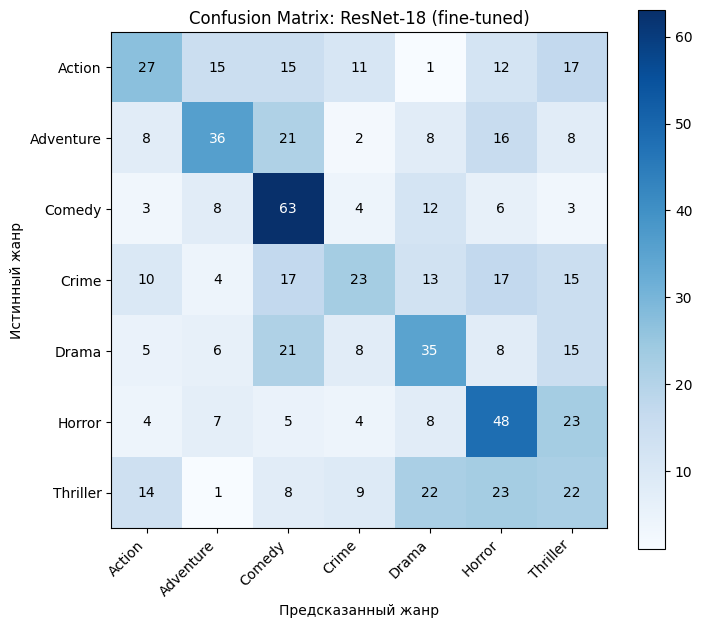

In [128]:
best_preds = {'CNN from scratch': preds_cnn, 'ResNet-18 (fine-tuned)': preds_resnet, 'EfficientNet-B0': preds_effnet}[best_name]
best_labels = {'CNN from scratch': labels_cnn, 'ResNet-18 (fine-tuned)': labels_resnet, 'EfficientNet-B0': labels_effnet}[best_name]

cm = confusion_matrix(best_labels, best_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(genre_classes)))
ax.set_yticks(range(len(genre_classes)))
ax.set_xticklabels(genre_classes, rotation=45, ha='right')
ax.set_yticklabels(genre_classes)
ax.set_xlabel('Предсказанный жанр')
ax.set_ylabel('Истинный жанр')
ax.set_title(f'Confusion Matrix: {best_name}')

for i in range(len(genre_classes)):
    for j in range(len(genre_classes)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.savefig('../data/processed/cv_confusion_matrix.png')
plt.show()

Видны систематические смешения, отражающие визуальное сходство жанров. Comedy выделяется лучше всего — вероятно, характерная цветовая палитра и композиция. Action и Adventure путаются друг с другом в обе стороны — оба жанра визуально тяготеют к динамичным сценам. Thriller — наиболее проблемный класс: лишь 22 правильных предсказания из 99, с равномерным "рассеиванием" ошибок по Drama (22), Horror (23), Crime (9) — жанр визуально размыт между несколькими соседними категориями. Drama и Comedy также заметно путаются (21 в обе стороны) — оба жанра не имеют доминирующей характерной визуальной палитры в отличие от, например, Horror.

## 10. Genre Match Score

Используем лучшую модель чтобы посчитать **genre_match_score** для всех 6909
изображений — это вероятность (softmax), которую модель присваивает *истинному*
жанру фильма. Низкий score = постер плохо передаёт жанр.

Этот признак пойдёт обратно в EDA (`01_eda.ipynb`) для проверки гипотезы:
коррелирует ли genre_match_score с vote_average.

In [ ]:
best_model = {'CNN from scratch': model_cnn, 'ResNet-18 (fine-tuned)': model_resnet, 'EfficientNet-B0': model_effnet}[best_name]

full_ds = PosterDataset(df, POSTERS_DIR, eval_transform)
full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

best_model.eval()
all_probs_full = []
with torch.no_grad():
    for images, labels in full_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = F.softmax(outputs, dim=1)
        all_probs_full.append(probs.cpu().numpy())

all_probs_full = np.concatenate(all_probs_full)

df['genre_match_score'] = [all_probs_full[i, df['genre_idx'].iloc[i]] for i in range(len(df))]

       id                                            title primary_genre  \
0  442094                                      Check Point        Action   
1    1885                                   The Karate Kid        Action   
2   64635                                     Total Recall        Action   
3   39276                                King Kong Escapes        Action   
4  447200                                       Skyscraper        Action   
5  228805  Detective Conan: Private Eye in the Distant Sea        Action   
6   26480              The Legend of the 7 Golden Vampires        Action   
7  619297                                       Sweet Girl        Action   
8  256740                                     Wicked Blood        Action   
9   13481                                  The Five Venoms        Action   

   genre_match_score  vote_average  
0           0.779666         6.373  
1           0.109752         7.181  
2           0.315398         6.000  
3           0.4

In [130]:
df[['id', 'title', 'primary_genre', 'genre_match_score', 'vote_average']].head(10)

,id,title,primary_genre,genre_match_score,vote_average
0,442094,Check Point,Action,0.779666,6.373
1,1885,The Karate Kid,Action,0.109752,7.181
2,64635,Total Recall,Action,0.315398,6.000
3,39276,King Kong Escapes,Action,0.415430,6.200
4,447200,Skyscraper,Action,0.708274,6.318
5,228805,Detective Conan: Private Eye in the Distant Sea,Action,0.274354,6.606
6,26480,The Legend of the 7 Golden Vampires,Action,0.035173,5.887
7,619297,Sweet Girl,Action,0.145714,6.682
8,256740,Wicked Blood,Action,0.192234,5.449
9,13481,The Five Venoms,Action,0.138715,6.671


In [131]:
df['genre_match_score'].mean()

np.float32(0.30570188)

Средний genre_match_score

Сохраняем для использования в EDA-ноутбуке:

In [ ]:
df[['id', 'title', 'primary_genre', 'genre_match_score']].to_csv(
    '../data/processed/genre_match_scores.csv', index=False
)
print('Сохранено: data/processed/genre_match_scores.csv')

Сохранено: data/processed/genre_match_scores.csv


Проверим гипотезу о соответствии постера жанру и какой от этого рейтинг

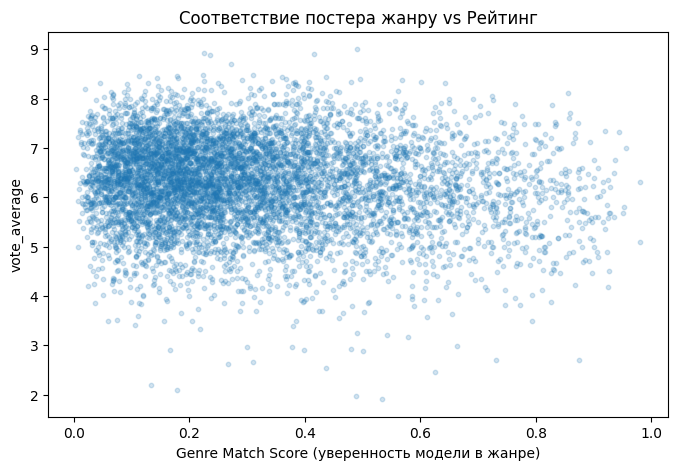

In [133]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['genre_match_score'], df['vote_average'], alpha=0.2, s=10)
ax.set_xlabel('Genre Match Score (уверенность модели в жанре)')
ax.set_ylabel('vote_average')
ax.set_title('Соответствие постера жанру vs Рейтинг')
plt.savefig('../data/processed/genre_match_vs_rating.png')
plt.show()

Scatter-plot не показывает выраженной визуальной связи — облако точек равномерно распределено по всему диапазону genre_match_score без видимого тренда. Это согласуется с тем, что использованная для расчёта score модель (ResNet-18, Accuracy=0.368) имеет существенный уровень шума — почти две трети предсказаний неточны, что напрямую снижает надёжность genre_match_score как признака. Прямой количественной (числовой) проверки корреляции на этом прогоне не проводилось.

In [132]:
corr = df['genre_match_score'].corr(df['vote_average'])
corr

np.float64(-0.12300314342909516)

Корреляция genre_match_score vs vote_average

Проверим по жанрам: какие жанры наиболее чувствительны к соответствию постера

In [134]:
genre_sensitivity = df.groupby('primary_genre').apply(
    lambda g: g['genre_match_score'].corr(g['vote_average'])
).sort_values(ascending=False)

genre_sensitivity

/var/folders/mf/gpk354fs7md1m_w2r26tz7400000gn/T/ipykernel_31547/2514169523.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_sensitivity = df.groupby('primary_genre').apply(


primary_genre
Adventure    0.034089
Drama        0.030337
Thriller    -0.004603
Crime       -0.009071
Action      -0.101055
Horror      -0.101148
Comedy      -0.118395
dtype: float64

Корреляция genre_match_score vs vote_average по жанрам

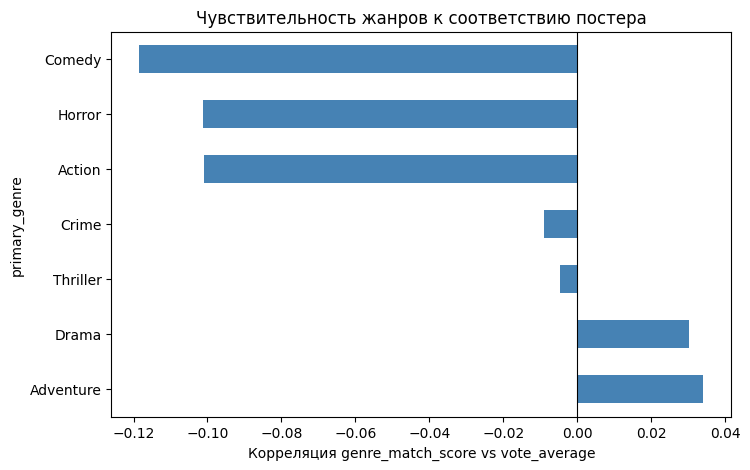

In [135]:
fig, ax = plt.subplots(figsize=(8, 5))
genre_sensitivity.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Корреляция genre_match_score vs vote_average')
ax.set_title('Чувствительность жанров к соответствию постера')
ax.axvline(0, color='black', linewidth=0.8)
plt.savefig('../data/processed/genre_sensitivity.png')
plt.show()

## Бизнес-рекомендация
Уже на текущем этапе модель демонстрирует рабочий принцип: genre_match_score можно автоматически рассчитывать для любого фильма в каталоге и использовать как первичный фильтр — выявлять кандидатов с потенциально неудачным визуальным представлением для дальнейшей ручной проверки редакцией, а не как окончательное решение. Это уже сокращает объём работы для команды контента — вместо просмотра всего каталога, проверке подлежит только подмножество с низким score. По мере роста объёма обучающих данных (больше постеров на жанр) и более бережной настройки fine-tuning точность будет расти, что в перспективе позволит перейти от рекомендательного фильтра к более автоматизированным решениям — вплоть до прямых предложений по замене постера для конкретных фильмов с высоким бизнес-потенциалом, но слабым визуальным соответствием жанру.